# NYC Taxi Fare Analytics — 2020–2024

A real-data walkthrough of yellow and green taxi ingestion, cleaning, storage, exploratory analysis, feature engineering and Spark regression. Saved outputs come from the verified five-year local experiment.

Run cells in order. The default reads compact published results, so it also works after cloning without downloading the full dataset. Set `RECOMPUTE = True` in the next cell to download all 120 monthly files and rerun the full pipeline. This takes substantially longer than reading the results.

The target is **completed-trip metered fare**, using realized distance and duration. It is not a pre-trip quote or total passenger spending. The quick synthetic demo remains available separately with `nyc-taxi demo`.


In [1]:
from pathlib import Path
import csv
import json
import subprocess
import sys
import os
from IPython.display import Markdown, display, Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
RECOMPUTE = False
RUN_ROOT = ROOT / "outputs/full-five-year/real"
RESULTS = ROOT / "docs/results"

if RECOMPUTE:
    subprocess.run([sys.executable, "-m", "nyc_taxi.cli", "download"], check=True)
    subprocess.run([sys.executable, "-m", "nyc_taxi.cli", "run", "--output", "outputs/full-five-year"], check=True)
    subprocess.run([sys.executable, "-m", "nyc_taxi.reporting", "--run", str(RUN_ROOT)], check=True)

experiment = json.loads((RESULTS / "experiment.json").read_text())
fleets = experiment["fleets"]

def table(records, columns=None):
    if not records:
        display(Markdown("No records meet this analysis's criteria."))
        return
    columns = columns or list(records[0])
    def formatted(value, column):
        if column in ("year", "month", "distance_bin", "payment_type"):
            return str(value)
        if isinstance(value, int):
            return f"{value:,}"
        if isinstance(value, float):
            return f"{value:,.4f}"
        try:
            if str(value).isdigit():
                return f"{int(value):,}"
            return f"{float(value):,.4f}"
        except (ValueError, TypeError):
            return str(value)
    content = "| " + " | ".join(columns) + " |\n"
    content += "| " + " | ".join("---" for _ in columns) + " |\n"
    for record in records:
        content += "| " + " | ".join(formatted(record.get(c, ""), c) for c in columns) + " |\n"
    display(Markdown(content))

def csv_rows(fleet, name):
    with (RESULTS / fleet / name).open() as stream:
        return list(csv.DictReader(stream))

print("Real TLC data; fleets:", ", ".join(fleets))
print("Years:", fleets["yellow"]["years"])


Real TLC data; fleets: yellow, green
Years: [2020, 2021, 2022, 2023, 2024]


## 1. Ingestion and source coverage

The downloader retries network failures, checks Parquet metadata, and publishes files atomically. All requested months must be present. The main run uses compressed Parquet; CSV conversion is optional and uses additional space.

The manifest provides provenance for the actual inputs, including filenames, byte sizes and row counts. It is not a cryptographic content lock.


In [2]:
manifest = json.loads((RESULTS / "download-manifest.json").read_text())
coverage = []
for fleet, run in fleets.items():
    source_files = run["source_files"]
    coverage.append({"fleet": fleet, "monthly_files": len(source_files),
                     "raw_rows": f"{sum(item['rows'] for item in source_files):,}",
                     "first_file": source_files[0]["file"], "last_file": source_files[-1]["file"]})
table(coverage)
assert all(row["monthly_files"] == 60 for row in coverage)
assert len(manifest) == 120


| fleet | monthly_files | raw_rows | first_file | last_file |
| --- | --- | --- | --- | --- |
| yellow | 60 | 174,689,444 | yellow_tripdata_2020-01.parquet | yellow_tripdata_2024-12.parquet |
| green | 60 | 5,090,611 | green_tripdata_2020-01.parquet | green_tripdata_2024-12.parquet |


## 2. Cleaning and schema normalization

Yellow uses `tpep_*` timestamps and green uses `lpep_*`. Each monthly file is projected onto the same typed schema before a name-based union. Cleaning rejects missing timestamps, pickup years outside the requested period, nonfinite/nonpositive fare or distance, and nonpositive duration.

Each row has one first-failure reason, so accepted plus rejected counts reconcile to the source total. Passenger counts are retained even when missing because they are not a model input. Extreme positive measurements remain in the cleaned data for inspection.


In [3]:
quality_rows = []
for fleet, run in fleets.items():
    for reason, count in sorted(run["quality"].items()):
        quality_rows.append({"fleet": fleet, "reason": reason, "rows": f"{count:,}"})
    assert sum(run["quality"].values()) == sum(source["rows"] for source in run["source_files"])
table(quality_rows)


| fleet | reason | rows |
| --- | --- | --- |
| yellow | accepted | 170,265,054 |
| yellow | invalid_distance | 2,863,932 |
| yellow | invalid_duration | 82,583 |
| yellow | invalid_fare | 1,476,671 |
| yellow | outside_period | 1,204 |
| green | accepted | 4,845,392 |
| green | invalid_distance | 229,226 |
| green | invalid_duration | 1,071 |
| green | invalid_fare | 14,811 |
| green | outside_period | 111 |


## 3. Full storage and portable SQLite inspection

Every accepted trip is saved in cleaned Parquet. SQLite contains an explicitly bounded snapshot of at most 100,000 accepted rows per fleet, which is verified before replacing the database. This saves local storage and supports portable SQL inspection. The snapshot is not a representative modeling sample and is not used for EDA.

For an optional full SQLite export, use `--sqlite-limit 0` with sufficient disk space. The main experiment's measured scope is recorded below.


In [4]:
table([{"fleet": fleet, "full_cleaned_rows": f"{run['full_cleaned_rows']:,}",
        "sqlite_rows": f"{run['sqlite_rows']:,}", "sqlite_scope": run["sqlite_scope"]}
       for fleet, run in fleets.items()])

import sqlite3
for fleet in fleets:
    database = RUN_ROOT / fleet / f"nyc_{fleet}_taxi.db"
    if database.exists():
        with sqlite3.connect(database) as connection:
            count = connection.execute("SELECT COUNT(*) FROM trips").fetchone()[0]
            integrity = connection.execute("PRAGMA integrity_check").fetchone()[0]
        assert count == fleets[fleet]["sqlite_rows"]
        assert integrity == "ok"
        print(f"{fleet}: SQL count={count:,}, integrity={integrity}")
    else:
        print(f"{fleet}: SQLite binary is excluded from Git; its verified scope is recorded above.")


| fleet | full_cleaned_rows | sqlite_rows | sqlite_scope |
| --- | --- | --- | --- |
| yellow | 170,265,054 | 100,000 | bounded_snapshot |
| green | 4,845,392 | 100,000 | bounded_snapshot |


yellow: SQL count=100,000, integrity=ok
green: SQL count=100,000, integrity=ok


## 4. Exploratory analysis on all accepted trips

Spark SQL and DataFrame aggregations cover pickup zones, hour, month, distance-bin fares, highest-fare drop-offs, weekdays/weekends, trips over 10 miles, payment methods and fare distribution.

Drop-off rankings require at least 500 trips. Weekday/weekend averages use observed dates, not a complete calendar. The summaries describe trips with positive recorded fares, not confirmed settled payments. Codes 0 and 3–6 and missing payment information remain when other cleaning rules pass.


### Yellow demand

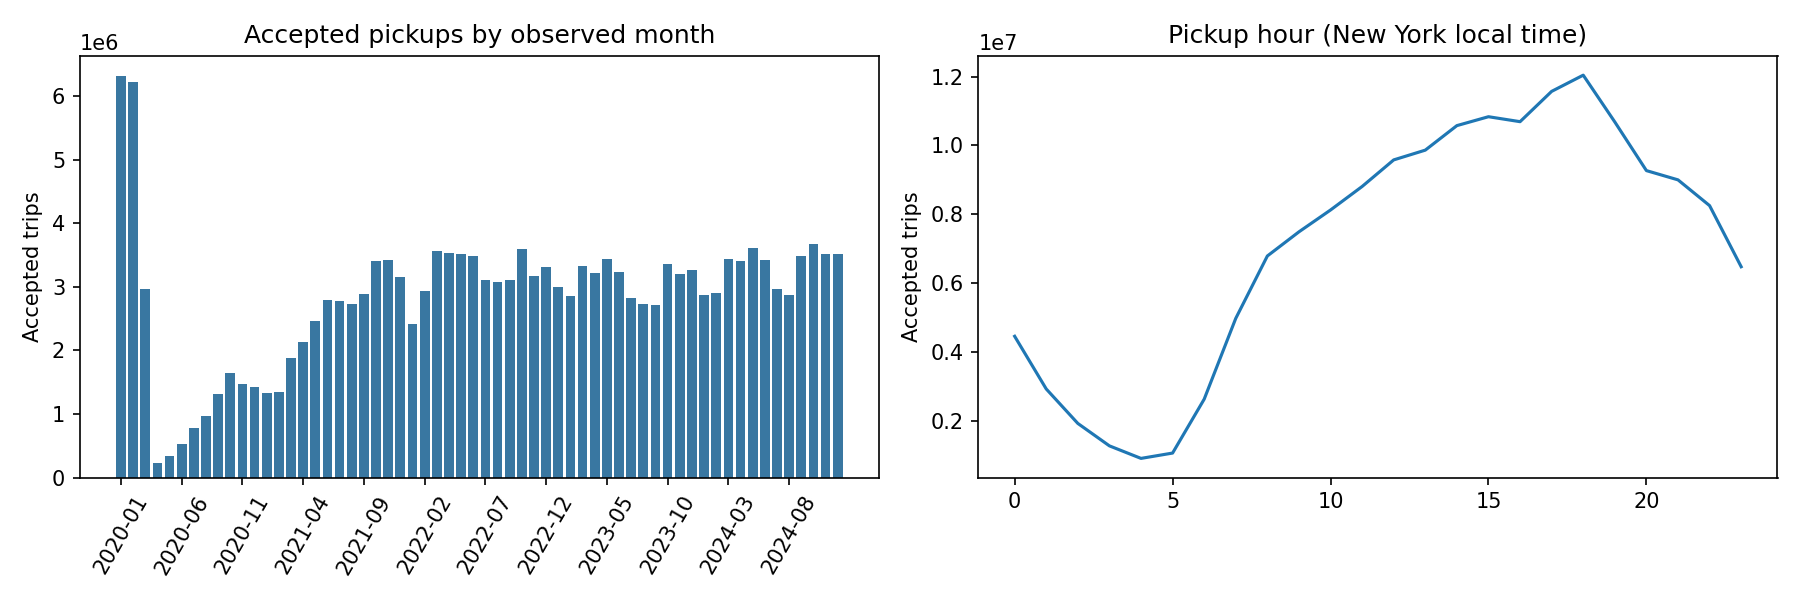

**Average metered fare by distance interval**

| distance_bin | trip_count | mean_fare |
| --- | --- | --- |
| 0-1 | 35,591,491 | 6.9354 |
| 1-2 | 56,682,815 | 9.9804 |
| 2-5 | 49,613,076 | 16.2076 |
| 5-10 | 15,126,649 | 29.4518 |
| 10-20 | 11,551,543 | 53.5300 |
| 20+ | 1,699,480 | 78.0494 |


**Highest average fare drop-offs (at least 500 trips)**

| DOLocationID | trip_count | mean_fare |
| --- | --- | --- |
| 204 | 816 | 98.2383 |
| 84 | 1,474 | 96.7661 |
| 44 | 3,608 | 92.2023 |
| 265 | 570,046 | 90.5858 |
| 1 | 409,669 | 84.3075 |


**Weekday/weekend comparison**

| day_type | trip_count | observed_days | trips_per_observed_day |
| --- | --- | --- | --- |
| Weekend | 45,360,787 | 522 | 86,898.0594 |
| Weekday | 124,904,267 | 1,305 | 95,712.0820 |


### Green demand

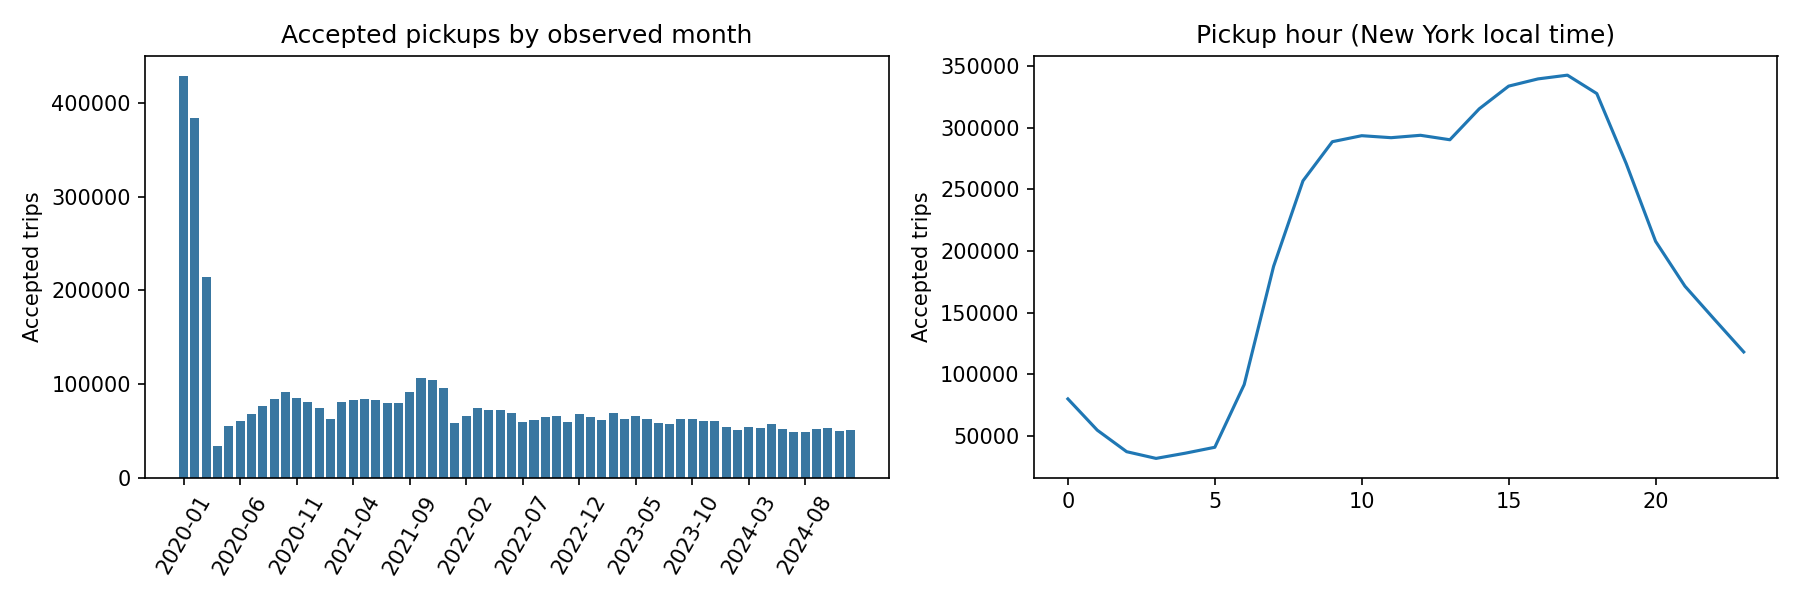

**Average metered fare by distance interval**

| distance_bin | trip_count | mean_fare |
| --- | --- | --- |
| 0-1 | 755,746 | 7.5448 |
| 1-2 | 1,397,414 | 9.8797 |
| 2-5 | 1,603,048 | 16.5061 |
| 5-10 | 694,610 | 28.4726 |
| 10-20 | 330,449 | 46.4534 |
| 20+ | 64,125 | 71.0663 |


**Highest average fare drop-offs (at least 500 trips)**

| DOLocationID | trip_count | mean_fare |
| --- | --- | --- |
| 1 | 2,530 | 88.7359 |
| 23 | 1,545 | 74.1300 |
| 156 | 807 | 67.3033 |
| 265 | 19,109 | 60.7696 |
| 115 | 783 | 50.4201 |


**Weekday/weekend comparison**

| day_type | trip_count | observed_days | trips_per_observed_day |
| --- | --- | --- | --- |
| Weekend | 1,159,722 | 522 | 2,221.6897 |
| Weekday | 3,685,670 | 1,305 | 2,824.2682 |


In [5]:
for fleet in fleets:
    display(Markdown(f"### {fleet.title()} demand"))
    display(Image(filename=str(RESULTS / fleet / "demand.png")))
    display(Markdown("**Average metered fare by distance interval**"))
    order = {"0-1": 0, "1-2": 1, "2-5": 2, "5-10": 3, "10-20": 4, "20+": 5}
    table(sorted(csv_rows(fleet, "fare_by_distance.csv"), key=lambda r: order[r["distance_bin"]]))
    display(Markdown("**Highest average fare drop-offs (at least 500 trips)**"))
    table(csv_rows(fleet, "highest_fare_dropoffs.csv"))
    display(Markdown("**Weekday/weekend comparison**"))
    table(csv_rows(fleet, "weekend_weekday.csv"))


In [6]:
for fleet in fleets:
    hourly = csv_rows(fleet, "hourly_trips.csv")
    busiest = max(hourly, key=lambda row: int(row["count"]))
    fare = {row["summary"]: row["fare_amount"] for row in csv_rows(fleet, "fare_distribution.csv")}
    monthly = csv_rows(fleet, "monthly_trips.csv")
    annual = {}
    for row in monthly:
        year = row["month"][:4]
        annual[year] = annual.get(year, 0) + int(row["count"])
    display(Markdown(f"**{fleet.title()} findings:** the busiest pickup hour was {int(busiest['pickup_hour']):02d}:00. "
                     f"Median metered fare was ${float(fare['50%']):.2f}, compared with a maximum of ${float(fare['max']):,.2f}. "
                     "The gap motivates examining tail errors rather than relying only on an average score."))
    table([{"year": year, "accepted_trips": f"{count:,}"} for year, count in sorted(annual.items())])
    display(Markdown("**Payment categories: methods, statuses and missing information**"))
    table(csv_rows(fleet, "payment_methods.csv"))
    display(Markdown("**Trips longer than 10 miles**"))
    table(csv_rows(fleet, "long_trip_fares.csv"))


**Yellow findings:** the busiest pickup hour was 18:00. Median metered fare was $11.40, compared with a maximum of $998,310.03. The gap motivates examining tail errors rather than relying only on an average score.

| year | accepted_trips |
| --- | --- |
| 2020 | 24,207,122 |
| 2021 | 30,328,457 |
| 2022 | 38,839,545 |
| 2023 | 37,185,685 |
| 2024 | 39,704,245 |


**Payment categories: methods, statuses and missing information**

| payment_type | count | payment_label | category_group |
| --- | --- | --- | --- |
| 1 | 129,079,036 | Credit card | Payment method |
| 2 | 31,629,374 | Cash | Payment method |
| 0 | 8,174,132 | Flex Fare (current TLC definition) | Fare regime |
| 4 | 791,941 | Dispute | Payment status |
| 3 | 590,556 | No charge | Payment status |
| 5 | 15 | Unknown (reported code) | Unknown |


**Trips longer than 10 miles**

...

| year | accepted_trips |
| --- | --- |
| 2020 | 1,661,843 |
| 2021 | 1,025,083 |
| 2022 | 788,852 |
| 2023 | 745,661 |
| 2024 | 623,953 |


**Payment categories: methods, statuses and missing information**

| payment_type | count | payment_label | category_group |
| --- | --- | --- | --- |
| 1 | 2,308,044 | Credit card | Payment method |
| 2 | 1,428,595 | Cash | Payment method |
|  | 1,093,367 | Missing payment information | Missing |
| 3 | 11,492 | No charge | Payment status |
| 4 | 3,815 | Dispute | Payment status |
| 5 | 79 | Unknown (reported code) | Unknown |


**Trips longer than 10 miles**

| trip_count | mean_fare |
| --- | --- |
| 393,585 | 50.4860 |


### Interpreting payment categories

Card (1) and cash (2) identify payment methods. No charge (3), dispute (4) and voided trip (6) describe status. Reported unknown (5) is separate from missing information.

The supplied older dictionaries omit zero. The [March 2025 TLC dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf) defines **0 as Flex Fare**; this is labeled as the current definition, without claiming it was independently verified for every historical record. The zeros and green nulls are present in the raw source files.

A positive recorded fare does not establish payment settlement. All these categories remain if the other cleaning rules pass, and payment type is not a model input. The existing model results are unchanged; a card/cash-only model comparison is optional future work.


## 5. Feature engineering and training-only preprocessing

The model uses realized distance/duration, pickup hour, weekday, month, pickup zone, drop-off zone and distance bin. Location IDs and distance bins are one-hot encoded. Encoders and input caps are learned from training data only and then saved for later predictions.

Distance and duration inputs are capped at training-set 99.9th percentiles to assess sensitivity to extreme measurements. Raw columns and target fares remain unchanged. Payment method, final rate code, tips and total amount are excluded from inputs.

The preview below comes from the bounded SQLite snapshot and illustrates feature definitions; it does not describe the modeling sample distribution.


In [7]:
from nyc_taxi.pipeline import NUMERIC, CATEGORICAL
print("Numeric feature definitions:", NUMERIC)
print("Categorical feature definitions:", CATEGORICAL)
for fleet, run in fleets.items():
    display(Markdown(f"### {fleet.title()} feature preview"))
    table(csv_rows(fleet, "feature_preview.csv"),
          ["trip_distance", "duration_minutes", "pickup_hour", "pickup_weekday", "pickup_month", "distance_bin"])
    print("Training-learned caps:", run["modeling"]["training_input_caps_p999"])


Numeric feature definitions: ['trip_distance', 'duration_minutes', 'pickup_hour', 'pickup_weekday', 'pickup_month']
Categorical feature definitions: ['PULocationID', 'DOLocationID', 'distance_bin']


### Yellow feature preview

| trip_distance | duration_minutes | pickup_hour | pickup_weekday | pickup_month | distance_bin |
| --- | --- | --- | --- | --- | --- |
| 0.7000 | 4.4000 | 17 | 7 | 1 | 0-1 |
| 4.2300 | 17.3667 | 3 | 7 | 1 | 2-5 |
| 1.7000 | 8.8000 | 15 | 7 | 1 | 1-2 |
| 0.8700 | 7.5167 | 22 | 7 | 1 | 0-1 |
| 3.7900 | 18.7333 | 16 | 1 | 1 | 2-5 |
| 8.4400 | 15.6833 | 10 | 1 | 1 | 5-10 |
| 2.3300 | 11.8833 | 12 | 1 | 1 | 2-5 |
| 4.3500 | 18.3667 | 3 | 7 | 1 | 2-5 |


Training-learned caps: {'trip_distance': 28.2, 'duration_minutes': 1400.6666666666667}


### Green feature preview

| trip_distance | duration_minutes | pickup_hour | pickup_weekday | pickup_month | distance_bin |
| --- | --- | --- | --- | --- | --- |
| 3.7000 | 10.3167 | 4 | 5 | 1 | 2-5 |
| 1.8300 | 7.3500 | 15 | 1 | 1 | 1-2 |
| 5.6800 | 29.3667 | 16 | 5 | 1 | 5-10 |
| 0.6000 | 3.6833 | 20 | 6 | 1 | 0-1 |
| 2.9000 | 13.5333 | 12 | 5 | 1 | 2-5 |
| 2.4500 | 18.9833 | 15 | 7 | 1 | 2-5 |
| 2.2500 | 7.8833 | 1 | 1 | 1 | 2-5 |
| 1.4000 | 5.6833 | 19 | 5 | 1 | 1-2 |


Training-learned caps: {'trip_distance': 40.89, 'duration_minutes': 1411.05}


## 6. Train, compare sample sizes, and evaluate

Training uses 2020–2022, validation 2023, and test 2024. Starting sample fractions are 0.2% yellow and 5% green. Linear regression, random forest and gradient-boosted trees are compared using validation RMSE.

The selected regression family is then tried with a larger training sample, holding the validation/test samples fixed. The larger candidate is retained only if validation RMSE improves. The final candidate is evaluated once on the held-out test sample, with a training-mean baseline.


In [8]:
table([{"fleet": fleet, **run["modeling"]["split_counts"],
        "selected_training": run["modeling"]["selected_training_rows"]}
       for fleet, run in fleets.items()])
for fleet, run in fleets.items():
    m = run["modeling"]
    display(Markdown(f"### {fleet.title()} validation comparison"))
    table(m["validation"], ["model", "rmse", "mae", "r2"])
    display(Markdown("**Training-size sensitivity on the same validation records**"))
    table([{"training_rows": candidate["training_rows"], "training_fraction": candidate["training_fraction"],
            **candidate["validation"]} for candidate in m["sample_size_comparison"]])


| fleet | base_train | validation | test | selected_training |
| --- | --- | --- | --- | --- |
| yellow | 186,681 | 74,588 | 79,570 | 373,614 |
| green | 173,992 | 37,329 | 31,158 | 347,393 |


### Yellow validation comparison

| model | rmse | mae | r2 |
| --- | --- | --- | --- |
| LinearRegression | 9.3082 | 5.5374 | 0.7311 |
| RandomForestRegressor | 9.0576 | 5.2164 | 0.7454 |
| GBTRegressor | 8.4334 | 4.9902 | 0.7793 |


**Training-size sensitivity on the same validation records**

| training_rows | training_fraction | rmse | mae | r2 |
| --- | --- | --- | --- | --- |
| 186,681 | 0.0020 | 8.4334 | 4.9902 | 0.7793 |
| 373,614 | 0.0040 | 8.4099 | 4.9968 | 0.7805 |


### Green validation comparison

| model | rmse | mae | r2 |
| --- | --- | --- | --- |
| LinearRegression | 23.4679 | 4.8867 | 0.2275 |
| RandomForestRegressor | 23.4729 | 4.0434 | 0.2271 |
| GBTRegressor | 23.4533 | 4.2142 | 0.2284 |


**Training-size sensitivity on the same validation records**

| training_rows | training_fraction | rmse | mae | r2 |
| --- | --- | --- | --- | --- |
| 173,992 | 0.0500 | 23.4533 | 4.2142 | 0.2284 |
| 347,393 | 0.1000 | 23.3831 | 4.1884 | 0.2330 |


| fleet | selected_model | rmse | mae | r2 | baseline_rmse |
| --- | --- | --- | --- | --- | --- |
| yellow | GBTRegressor | 8.4360 | 5.2491 | 0.7702 | 18.6341 |
| green | GBTRegressor | 10.3825 | 4.3693 | 0.6009 | 16.4513 |


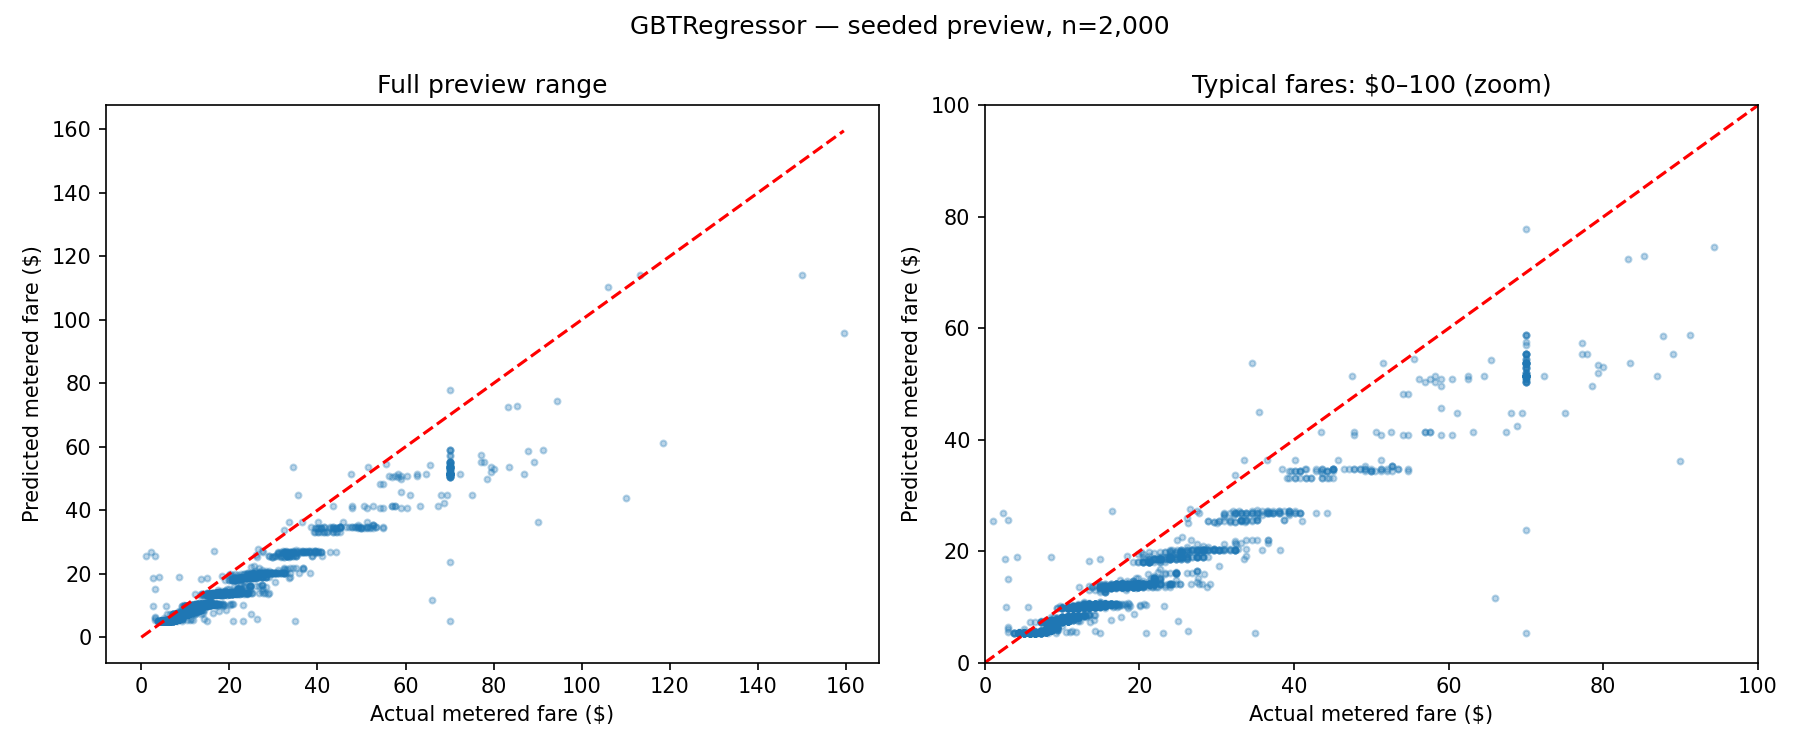

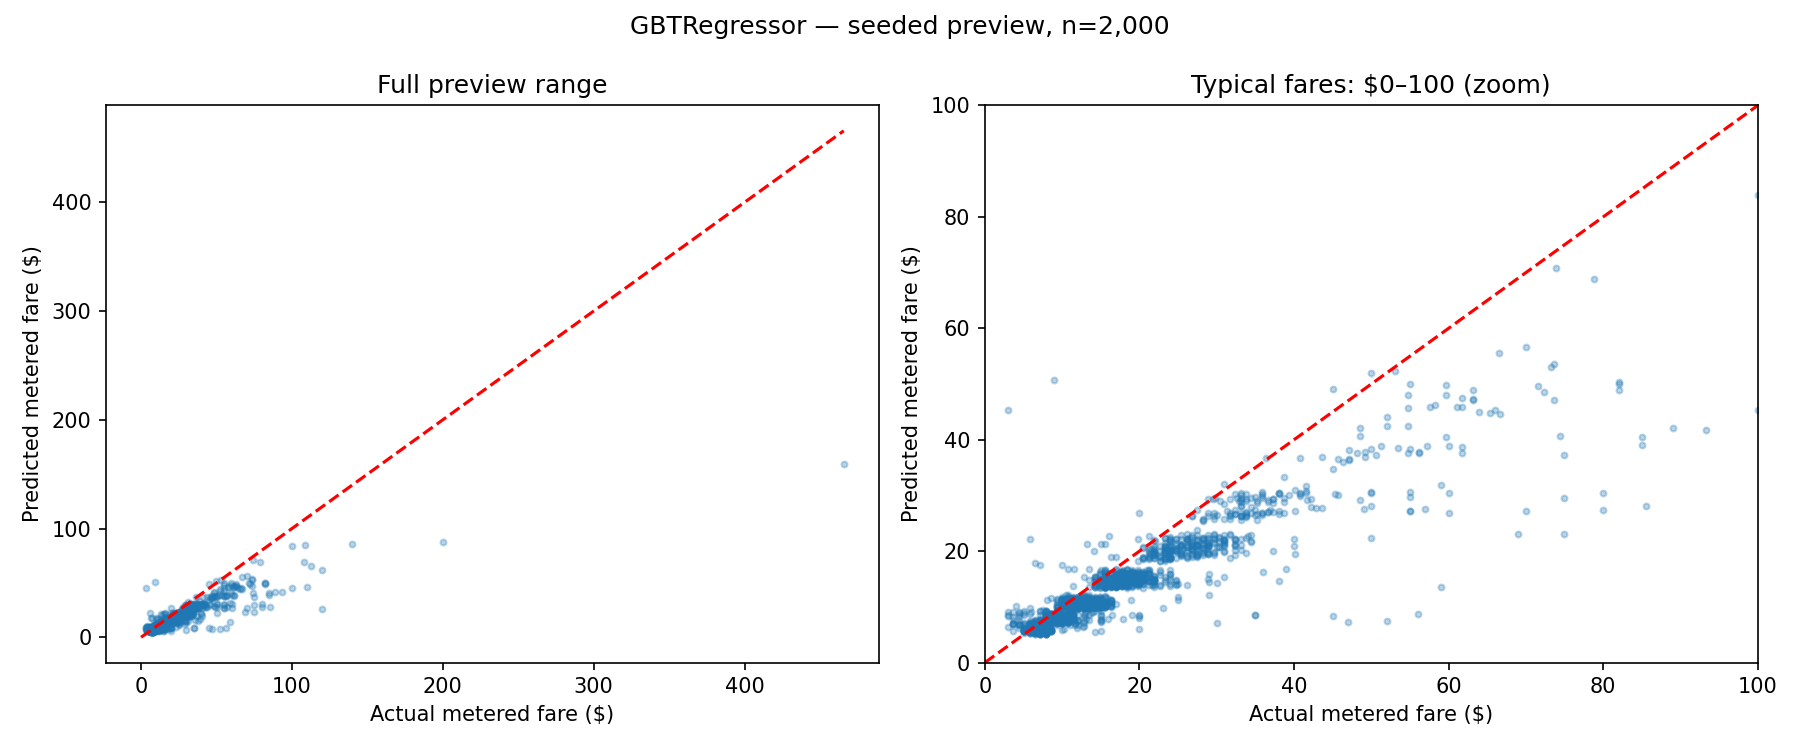

In [9]:
table([{"fleet": fleet, "selected_model": run["modeling"]["selected_model"],
        **run["modeling"]["test"], "baseline_rmse": run["modeling"]["mean_baseline_test"]["rmse"]}
       for fleet, run in fleets.items()])
for fleet in fleets:
    display(Image(filename=str(RESULTS / fleet / "actual_vs_predicted.png")))


## Error analysis

An uncapped linear-regression comparison uses the same base training and validation records. Compare its scores and worst residuals with capped inputs. The difference measures sensitivity to input treatment, without proving that every extreme record is invalid.

Prediction plots use up to 2,000 seeded hash-selected test records. Their zoomed panel shows typical fares; metrics include the full test sample. Errors by fare band show whether large fares remain difficult.


In [10]:
for fleet, run in fleets.items():
    m = run["modeling"]
    capped = next(result for result in m["validation"] if result["model"] == "LinearRegression")
    display(Markdown(f"### {fleet.title()} linear-regression sensitivity"))
    table([{"variant": "uncapped", **m["uncapped_linear_validation"]},
           {"variant": "training-only input caps", **{key: capped[key] for key in ("rmse", "mae", "r2")}}])
    print("Share of uncapped squared error from the 20 worst records:",
          f"{m['uncapped_linear_diagnostics']['worst_20_share_of_squared_error']:.1%}")
    table(csv_rows(fleet, "validation_linear_uncapped_worst_errors.csv")[:5])
    display(Markdown("**Held-out errors by actual fare band**"))
    table(csv_rows(fleet, "test_selected_error_by_fare.csv"))


### Yellow linear-regression sensitivity

| variant | rmse | mae | r2 |
| --- | --- | --- | --- |
| uncapped | 9.8776 | 5.7230 | 0.6972 |
| training-only input caps | 9.3082 | 5.5374 | 0.7311 |


Share of uncapped squared error from the 20 worst records: 15.9%


| pickup_datetime | trip_distance | duration_minutes | fare_amount | prediction | absolute_error |
| --- | --- | --- | --- | --- | --- |
| 2023-06-27 22:56:32 | 241.0000 | 249.6167 | 700.0000 | 88.1926 | 611.8074 |
| 2023-01-12 13:11:21 | 55.3600 | 69.7333 | 370.5000 | 89.4150 | 281.0850 |
| 2023-03-07 06:15:21 | 56.5400 | 67.6333 | 333.4000 | 89.3556 | 244.0444 |
| 2023-01-17 15:29:56 | 60.8300 | 98.7333 | 330.6000 | 89.4759 | 241.1241 |
| 2023-11-23 21:25:31 | 50.8600 | 60.9333 | 325.0000 | 83.9148 | 241.0852 |


**Held-out errors by actual fare band**

...

| variant | rmse | mae | r2 |
| --- | --- | --- | --- |
| uncapped | 23.6964 | 5.0480 | 0.2124 |
| training-only input caps | 23.4679 | 4.8867 | 0.2275 |


Share of uncapped squared error from the 20 worst records: 86.5%


| pickup_datetime | trip_distance | duration_minutes | fare_amount | prediction | absolute_error |
| --- | --- | --- | --- | --- | --- |
| 2023-06-02 11:35:41 | 80.0000 | 0.1167 | 4,003.0000 | 59.2751 | 3,943.7249 |
| 2023-08-30 19:57:38 | 27.0900 | 822.3333 | 1,256.7000 | 80.2445 | 1,176.4555 |
| 2023-12-28 23:57:03 | 0.0200 | 0.0833 | 449.9900 | 10.2413 | 439.7487 |
| 2023-10-05 13:18:14 | 36.4800 | 517.8333 | 404.8000 | 65.1661 | 339.6339 |
| 2023-11-17 12:37:58 | 33.3800 | 509.0000 | 396.4000 | 65.3236 | 331.0764 |


**Held-out errors by actual fare band**

| fare_band | rows | mae | rmse |
| --- | --- | --- | --- |
| 20_to_50 | 6,981 | 6.9508 | 8.2483 |
| 50_plus | 1,217 | 31.7070 | 47.2197 |
| under_20 | 22,960 | 2.1353 | 2.7226 |


## Reproduced verification failure

A separate three-month diagnostic reproduces the earlier yellow linear-regression failure. It uses the same 28,888 training records and 29,150 validation records, comparing uncapped and training-capped feature inputs. This explains a pipeline weakness; it is not the main five-year performance result.


In [11]:
diagnostic_root = RESULTS / "verification-error-investigation"
if (diagnostic_root / "investigation.json").exists():
    investigation = json.loads((diagnostic_root / "investigation.json").read_text())
    table([{"variant": name, **value["metrics"]} for name, value in investigation["variants"].items()])
    with (diagnostic_root / "uncapped_worst_errors.csv").open() as stream:
        worst_records = list(csv.DictReader(stream))
    table(worst_records[:3])
    display(Markdown("The leading record reports **6,860.8 miles in about 39 minutes** for a **$32.50 fare**. "
                     "Uncapped linear extrapolation predicted roughly **$18,057**. "
                     "On the same train/validation records, training-learned input caps reduced RMSE from **$105.71 to $5.32**. "
                     "This illustrates why both typical errors and extreme residuals need inspection."))
else:
    print("Optional diagnostic evidence is absent; reproduce with python -m nyc_taxi.investigate.")


| variant | rmse | mae | r2 |
| --- | --- | --- | --- |
| uncapped | 105.7113 | 3.2052 | -38.5338 |
| training_only_caps | 5.3179 | 1.7820 | 0.9000 |


| pickup_datetime | trip_distance | duration_minutes | fare_amount | prediction | absolute_error |
| --- | --- | --- | --- | --- | --- |
| 2024-02-29 13:17:33 | 6,860.8000 | 38.6167 | 32.5000 | 18,057.0327 | 18,024.5327 |
| 2024-02-08 21:38:21 | 65.5800 | 71.8500 | 422.3000 | 224.6008 | 197.6992 |
| 2024-02-02 08:44:45 | 0.0500 | 0.0833 | 200.0000 | 38.7005 | 161.2995 |


The leading record reports **6,860.8 miles in about 39 minutes** for a **$32.50 fare**. Uncapped linear extrapolation predicted roughly **$18,057**. On the same train/validation records, training-learned input caps reduced RMSE from **$105.71 to $5.32**. This illustrates why both typical errors and extreme residuals need inspection.

## Temporal pricing context

[TLC's official notice](https://www.nyc.gov/assets/tlc/downloads/pdf/industry-notices/industry_notice_22_02_english.pdf) documents a meter fare increase effective **19 December 2022**, near the end of training. Most training records precede that change; validation and test records follow it.

This is a plausible contributor to underestimation visible in the plots, not a measured causal explanation. The current feature set has no explicit pricing-regime variable. Rolling retraining or a known pricing-regime feature would require a new experiment, rather than adjusting these published scores.


## Measured runtime and limits

These are measured local results, not a cluster benchmark. Download time and this presentation notebook are excluded from the processing timer. The experiment uses modest fixed model settings, one seed and one temporal holdout. It does not quantify uncertainty across repeated samples.

The prediction uses realized trip measurements. Positive-fare filtering defines the analysis population. Training-only input caps can suppress genuine extreme behavior, so the residual tables and full-range plots should accompany performance claims.


In [12]:
table([{"fleet": fleet, **{stage: round(seconds / 60, 2) for stage, seconds in run["stage_seconds"].items()}}
       for fleet, run in fleets.items()])
print("Stage values above are minutes.")
print("Total processing minutes:", round(experiment["elapsed_seconds"] / 60, 2))
print(json.dumps(experiment["environment"], indent=2))


| fleet | load_clean_and_parquet_seconds | sqlite_seconds | eda_seconds | modeling_seconds |
| --- | --- | --- | --- | --- |
| yellow | 5.7000 | 0.2200 | 2.7700 | 3.9200 |
| green | 0.6900 | 0.0700 | 0.1400 | 1.7100 |


Stage values above are minutes.
Total processing minutes: 15.26
{
  "python": "3.9.6 (default, Apr 30 2025, 02:07:17) \n[Clang 17.0.0 (clang-1700.0.13.5)]",
  "spark": "3.5.3",
  "platform": "macOS-26.5-arm64-arm-64bit",
  "java": "java version \"17.0.12\" 2024-07-16 LTS\nJava(TM) SE Runtime Environment (build 17.0.12+8-LTS-286)\nJava HotSpot(TM) 64-Bit Server VM (build 17.0.12+8-LTS-286, mixed mode, sharing)",
  "master": "local[2]",
  "driver_memory": "4g",
  "timezone": "America/New_York"
}
